# _4.4.2. (Fine-Grained) classification using SVM_

Main topics of the current notebook is to focus on applying SVM to the problem of anomaly detection, i.e., identifying anomaly severity levels ranging from 5% to 50%, along with encompassing categories : reorder, duplicate, corrupt anpmalies or a normal case. 

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
from sklearn import svm, datasets
# import sklearn.model_selection as model_selection

In [2]:
from xgboost import XGBClassifier

import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os
import torch
import time 

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split

from scipy.stats import uniform, randint

from skopt import BayesSearchCV

%matplotlib inline

In [3]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(5)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0
2,-1.582333,-0.436192,-0.186196,-0.164204,-1.108483,0.193475,-0.664977,-0.665158,-0.460461,-0.978685,...,0.367256,-1.462647,0.524565,-0.964049,-0.045817,bad,0,-1.083746,False,0
3,-1.524596,-0.430804,-0.169590,-0.164204,-0.826439,0.384235,-0.245217,-0.244990,-0.363067,-0.799582,...,0.378520,-1.462647,0.524565,-0.956997,-0.045817,bad,0,-1.083746,False,0
4,-1.466860,-0.425614,-0.169846,-0.164204,-0.422082,0.397624,-0.242853,-0.242699,-0.259859,-0.665255,...,0.394329,-1.462647,0.524565,-0.943719,-0.045817,bad,0,-1.083746,False,0


In [5]:
n_total = len(scaled_new_df)
print ("n_total = ", n_total)
print ("nb features =", len(scaled_new_df.columns))
print ("nan values =", scaled_new_df.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


In [6]:
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level',  'Width',
                'Height', 'Play_Pos', 'RTT',  'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']
new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "tag"

In [7]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

The basic Idea here is to see the problem as a multi-class classification problem. 

The population is already devided into different anomalies tag using "tag" column.

In [9]:
# 'normal':0, 
# 'reorder5':1, 'reorder10':2, 'reorder20':3, 'reorder30':4, 'reorder40':5, 'reorder50':6,
# 'duplicate5':7, 'duplicate10':8, 'duplicate20':9, 'duplicate30':10, 'duplicate40':11, 'duplicate50':12,        
# 'corrupt5':13,   'corrupt10':14,   'corrupt20':15, 'corrupt30':16,  'corrupt40':17,  'corrupt50':18
train[target].value_counts(normalize=True)

0     0.253049
15    0.042058
3     0.042058
14    0.042058
1     0.042058
2     0.042058
7     0.042058
6     0.042058
13    0.042058
8     0.042058
9     0.042058
4     0.042058
16    0.042058
12    0.042058
5     0.042058
10    0.042058
11    0.042058
17    0.041182
18    0.032840
Name: tag, dtype: float64

#### _c. Split_

In [10]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (45650, 22)
shape(y_train) : (45650,)


#### _d. Check CUDA support_

In [11]:
print (torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

True


'cuda'

### _e. (multi-class) classification using SVM_

SVM is a supervised ML algorithm used for classification and regression tasks, particularly effective for classification tasks, 

The main objective in SVM is to find a hyperplane that best separates data points belonging to different classes in a high-dimensional space.

<br>

<div style="float: center;"><img  src="https://www.researchgate.net/profile/Joana-Cardoso-Fernandes/publication/343092219/figure/fig1/AS:915659655495680@1595321682060/The-support-vector-machines-SVM-method-the-optimal-hyperplane-separates-the-two_W640.jpg"  alt="SVM"  width="300"/>
</div>

</br>

We use **_sklearn.svm.SVC_**, the scikit-learn implementation of  _**C-Support Vector Classification**_. 

A _[[user_guide]](https://scikit-learn.org/stable/modules/svm.html#svm-classification)_ is available for more details about the implementation. More about the package itself is found _[[here]](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)_

> from sklearn import svm

Five kernels type are availables in the implementation, .e.g., _**‘linear’**, **‘poly’**, **‘rbf’**, **‘sigmoid’**, **‘precomputed’**_. 

We are concerned by two of them, namely : polynomial _**(poly)**_ and Radial Basis Function _**(RBF)**_.

##### _1. Polynomial_

In [12]:
poly = svm.SVC(kernel='poly', degree=3, C=1).fit(X_train, y_train)
poly_pred = poly.predict(X_test)

poly_accuracy = accuracy_score(y_test, poly_pred)
poly_f1 = f1_score(y_test, poly_pred, average='weighted')
print('\n Accuracy (Polynomial Kernel): ', "%.2f" % (poly_accuracy*100))
print('\n F1 (Polynomial Kernel): ', "%.2f" % (poly_f1*100))


 Accuracy (Polynomial Kernel):  49.22

 F1 (Polynomial Kernel):  41.81


In [13]:
y_pred = poly.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\n(SVM+Poly) Classification Report\n(Fine-Grained Anomaly Detection):\n")
print(classification_report(y_valid, y_pred))


(SVM+Poly) Classification Report:
(Fine-Grained Anomaly Detection)

              precision    recall  f1-score   support

           0       0.53      1.00      0.69      5831
           1       0.15      0.00      0.01       957
           2       0.20      0.01      0.01       973
           3       0.30      0.07      0.11       923
           4       0.27      0.18      0.22       954
           5       0.21      0.06      0.09      1001
           6       0.42      0.26      0.32       982
           7       0.39      0.26      0.31       970
           8       0.38      0.47      0.42       951
           9       0.27      0.09      0.13       953
          10       0.18      0.02      0.04       973
          11       0.22      0.59      0.32       928
          12       0.31      0.18      0.23       943
          13       0.39      0.10      0.16       962
          14       0.40      0.43      0.42       936
          15       0.82      0.77      0.79       951
          16

In [14]:
labaled_classes = [ 'normal', 
                    'reorder5', 'reorder10', 'reorder20', 
                    'reorder30', 'reorder40', 'reorder50',
                   'duplicate5', 'duplicate10', 'duplicate20', 
                    'duplicate30', 'duplicate40', 'duplicate50',        
                    'corrupt5',   'corrupt10',   'corrupt20', 
                    'corrupt30',  'corrupt40',  'corrupt50']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'reorder5', 'reorder10', 'reorder20', 'reorder30', 'reorder40', 'reorder50', 'duplicate5', 'duplicate10', 'duplicate20', 'duplicate30', 'duplicate40', 'duplicate50', 'corrupt5', 'corrupt10', 'corrupt20', 'corrupt30', 'corrupt40', 'corrupt50']
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


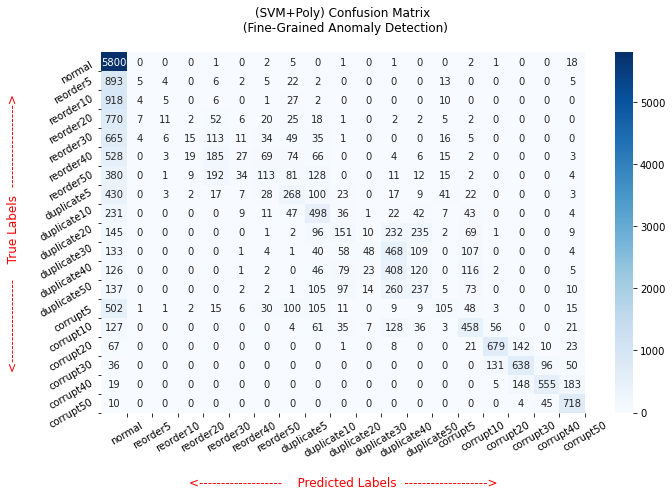

In [25]:
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("(SVM+Poly) Confusion Matrix\n (Fine-Grained Anomaly Detection)\n")
plt.tight_layout()
plt.show()

##### _2. RBF_

In [26]:
rbf = svm.SVC(kernel='rbf', gamma=0.5, C=0.1).fit(X_train, y_train)
rbf_pred = rbf.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_pred)
rbf_f1 = f1_score(y_test, rbf_pred, average='weighted')
print('\n Accuracy (RBF Kernel): ', "%.2f" % (rbf_accuracy*100))
print('\n F1 (RBF Kernel): ', "%.2f" % (rbf_f1*100))


 Accuracy (RBF Kernel):  47.34

 F1 (RBF Kernel):  39.03


In [17]:
y_pred = rbf.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("(SVM+RBF) Classification Report\n (Fine-Grained Anomaly Detection)\n")

(SVM+RBF) Classification Report
 (Fine-Grained Anomaly Detection)



In [23]:
labaled_classes = [ 'normal', 
                    'reorder5', 'reorder10', 'reorder20', 
                    'reorder30', 'reorder40', 'reorder50',
                   'duplicate5', 'duplicate10', 'duplicate20', 
                    'duplicate30', 'duplicate40', 'duplicate50',        
                    'corrupt5',   'corrupt10',   'corrupt20', 
                    'corrupt30',  'corrupt40',  'corrupt50']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'reorder5', 'reorder10', 'reorder20', 'reorder30', 'reorder40', 'reorder50', 'duplicate5', 'duplicate10', 'duplicate20', 'duplicate30', 'duplicate40', 'duplicate50', 'corrupt5', 'corrupt10', 'corrupt20', 'corrupt30', 'corrupt40', 'corrupt50']
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


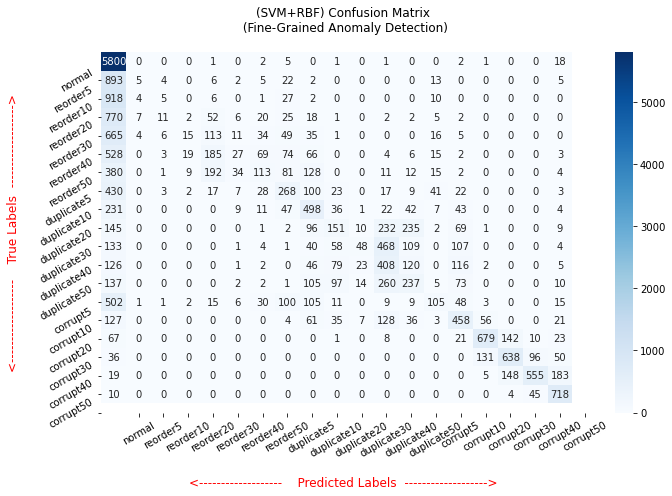

In [27]:
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("(SVM+RBF) Confusion Matrix\n (Fine-Grained Anomaly Detection)\n")
plt.tight_layout()
plt.show()

In [28]:
y_pred = rbf.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\n(SVM+RBF) Classification Report:\n(Fine-Grained Anomaly Detection)\n")
print(classification_report(y_valid, y_pred))


(SVM+RBF) Classification Report:
(Fine-Grained Anomaly Detection)

              precision    recall  f1-score   support

           0       0.49      0.99      0.65      5831
           1       0.24      0.01      0.01       957
           2       0.15      0.01      0.01       973
           3       0.04      0.00      0.00       923
           4       0.19      0.12      0.15       954
           5       0.25      0.03      0.05      1001
           6       0.35      0.12      0.17       982
           7       0.38      0.28      0.32       970
           8       0.38      0.52      0.44       951
           9       0.31      0.16      0.21       953
          10       0.47      0.05      0.09       973
          11       0.26      0.44      0.33       928
          12       0.29      0.25      0.27       943
          13       0.44      0.11      0.18       962
          14       0.47      0.49      0.48       936
          15       0.77      0.71      0.74       951
          16 